Hands-On Lab: Integrating and Analyzing the Model       
● Step 1: Wrap the project's preprocessing and model into a single predict() function taking raw input to a prediction.     
● Step 2: Verify prediction-time preprocessing exactly matches training-time preprocessing.     
● Step 3: Produce a confusion matrix and identify the model's most common error type.       
● Step 4: Pull out at least three misclassified examples, read them, and categorize each as a data issue or a model weakness in Markdown.       

#### Imports

In [59]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

import nltk
import string

from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
from nltk.stem import WordNetLemmatizer

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression

from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix
)

#### Load Dataset:

Reusing the same dataset as Sprint 3\day2 imdb reviews data !  

In [2]:
path = r"..\Data\IMDB Dataset of 50K Movie Reviews\IMDB Dataset.csv"

df = pd.read_csv(path) # header=None because this dataset does not use a normal header row

print(df.shape)
df.head()

(50000, 2)


,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [3]:
print(df.isnull().sum())
print("")
print("Duplicates:", df.duplicated().sum())

review       0
sentiment    0
dtype: int64

Duplicates: 418


In [4]:
df = df.drop_duplicates().reset_index(drop=True)

print("New shape:", df.shape)
print("Duplicates left:", df.duplicated().sum())

New shape: (49582, 2)
Duplicates left: 0


#### `Solo Functions` & tf-idf:

##### preprocessing (Cleaning text function)

In [10]:
# prepare stopwords
stop_words = set(stopwords.words("english"))

stop_words.discard("not")
stop_words.discard("no")
stop_words.discard("nor")

# create a lemmatizer
lemmatizer = WordNetLemmatizer()


# The functions
def preprocess_text(text):
    
    # 1- tokenize
    tokens = word_tokenize(text)
    
    # 2- lowercase
    tokens = [token.lower()
              for token in tokens]
    
    # 3- remove punctuation
    tokens = [token 
              for token in tokens
              if token not in string.punctuation]
    
    # 4- remove stop words
    tokens = [token
              for token in tokens
              if token not in stop_words]
    
    # 5- lemmatize
    tokens = [lemmatizer.lemmatize(token)
              for token in tokens]
    
    # JOIN back into text 
    cleaned_text = " ".join(tokens)
    
    return cleaned_text

In [12]:
def clean_review(raw_review):
    cleaned_review = preprocess_text(raw_review)
    return cleaned_review

##### X, Y Split

In [18]:
# Applying to the full dataset (if needed)
df["cleaned_review"] = df["review"].apply(preprocess_text)

# the Split
X = df["cleaned_review"]  # using the Cleeaned review data ! 
y = df["sentiment"]

X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=.2,random_state=42,stratify=y)

print("Y train distribution: ",y_train.value_counts())
print("\nY test distribution: ",y_test.value_counts())

Y train distribution:  sentiment
positive    19907
negative    19758
Name: count, dtype: int64

Y test distribution:  sentiment
positive    4977
negative    4940
Name: count, dtype: int64


##### TF-IDF vectorizer-transform and model-fit :

In [ ]:
# create vectorizer
tfidf = TfidfVectorizer(max_features=5000)  # vectorizer

X_train_tfidf = tfidf.fit_transform(X_train)

X_test_tfidf = tfidf.transform( X_test)


# Create and FIT classifier
tfidf_model = LogisticRegression(max_iter=1000) # model

tfidf_model.fit( X_train_tfidf , y_train)

,"max_iter max_iter: int, default=100Maximum number of iterations taken for the solvers to converge.",1000
,"penalty penalty: {'l1', 'l2', 'elasticnet', None}, default='l2'Specify the norm of the penalty:- `None`: no penalty is added;- `'l2'`: add an L2 penalty term and it is the default choice;- `'l1'`: add an L1 penalty term;- `'elasticnet'`: both L1 and L2 penalty terms are added... warning:: Some penalties may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionadded:: 0.19 l1 penalty with SAGA solver (allowing 'multinomial' + L1).. deprecated:: 1.8 `penalty` was deprecated in version 1.8 and will be removed in 1.10. Use `l1_ratio` and `C` instead. `l1_ratio=0` for `penalty='l2'`, `l1_ratio=1` for `penalty='l1'`, `l1_ratio` set to any float between 0 and 1 for `penalty='elasticnet'`, and `C=np.inf` for `penalty=None`.",'deprecated'
,"C C: float, default=1.0Inverse of regularization strength; must be a positive float.Like in support vector machines, smaller values specify strongerregularization. `C=np.inf` results in unpenalized logistic regression.For a visual example on the effect of tuning the `C` parameterwith an L1 penalty, see::ref:`sphx_glr_auto_examples_linear_model_plot_logistic_path.py`.",1.0
,"l1_ratio l1_ratio: float, default=0.0The Elastic-Net mixing parameter, with `0 <= l1_ratio <= 1`. Setting`l1_ratio=1` gives a pure L1-penalty, setting `l1_ratio=0` a pure L2-penalty.Any value between 0 and 1 gives an Elastic-Net penalty of the form`l1_ratio * L1 + (1 - l1_ratio) * L2`... warning:: Certain values of `l1_ratio`, i.e. some penalties, may not work with some solvers. See the parameter `solver` below, to know the compatibility between the penalty and solver... versionchanged:: 1.8 Default value changed from None to 0.0... deprecated:: 1.8 `None` is deprecated and will be removed in version 1.10. Always use `l1_ratio` to specify the penalty type.",0.0
,"dual dual: bool, default=FalseDual (constrained) or primal (regularized, see also:ref:`this equation <regularized-logistic-loss>`) formulation. Dual formulationis only implemented for l2 penalty with liblinear solver. Prefer `dual=False`when n_samples > n_features.",False
,"tol tol: float, default=1e-4Tolerance for stopping criteria.",0.0001
,"fit_intercept fit_intercept: bool, default=TrueSpecifies if a constant (a.k.a. bias or intercept) should beadded to the decision function.",True
,"intercept_scaling intercept_scaling: float, default=1Useful only when the solver `liblinear` is usedand `self.fit_intercept` is set to `True`. In this case, `x` becomes`[x, self.intercept_scaling]`,i.e. a ""synthetic"" feature with constant value equal to`intercept_scaling` is appended to the instance vector.The intercept becomes``intercept_scaling * synthetic_feature_weight``... note:: The synthetic feature weight is subject to L1 or L2 regularization as all other features. To lessen the effect of regularization on synthetic feature weight (and therefore on the intercept) `intercept_scaling` has to be increased.",1
,"class_weight class_weight: dict or 'balanced', default=NoneWeights associated with classes in the form ``{class_label: weight}``.If not given, all classes are supposed to have weight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.Note that these weights will be multiplied with sample_weight (passedthrough the fit method) if sample_weight is specified... versionadded:: 0.17 *class_weight='balanced'*",None
,"random_state random_state: int, RandomState instance, default=NoneUsed when ``solver`` == 'sag', 'saga' or 'liblinear' to shuffle thedata. See :term:`Glossary <random_state>` for details.",None
,"solver solver: {'lbfgs', 'liblinear', 'newton-cg', 'newton-cholesky', 'sag', 'saga'}, default='lbfgs'Algorithm to use in the optimization problem. Default is '

##### TF-IDF, Vectorizing function:

In [46]:
def vectorize_review(cleaned_review):
    
    vectorized_review =  tfidf.transform([cleaned_review])

    return vectorized_review 

##### Prediction function (using vectorized reviews)

In [47]:
def classify_review(vectorized_review):
    
    prediction = tfidf_model.predict(vectorized_review)[0]
    
    probabilities = tfidf_model.predict_proba(vectorized_review)[0]
    
    confidence = probabilities.max()
    
    return prediction, confidence

##### Testing each solo function:

In [ ]:
sample_review = "This movie was not good and I would never watch it again."

In [ ]:
cleaned = clean_review(sample_review)

print("Cleaned:")
print(cleaned)

Cleaned:
movie not good would never watch


In [49]:
vectorized = vectorize_review(cleaned)

print("Vectorized shape:",vectorized.shape)

Vectorized shape: (1, 5000)


In [51]:
prediction, confidence = classify_review(vectorized)

print("Prediction:", prediction)
print("Confidence:", confidence)

Prediction: negative
Confidence: 0.7557944281685071


### `Integrated PIPELINE`

In [ ]:
def predict_sentiment(raw_review):

    # 1. Clean raw text
    cleaned_review = clean_review(raw_review)

    # 2. Convert text into TF-IDF features
    vectorized_review = vectorize_review(cleaned_review)

    # 3. Make prediction
    prediction, confidence = classify_review(vectorized_review)

    return prediction, confidence

#### Testing pipeline (Single reviews)

In [53]:
# testing the pipeline with one review.

review = "The acting was excellent and the story was really enjoyable."

prediction, confidence = predict_sentiment(review)

print("Prediction:", prediction)
print("Confidence:", confidence)

Prediction: positive
Confidence: 0.9960336951541154


In [54]:
# testing the pipeline with one review.

review = "The movie was boring, badly written, and not enjoyable."

prediction, confidence = predict_sentiment(review)

print("Prediction:", prediction)
print("Confidence:", confidence)

Prediction: negative
Confidence: 0.9649559601562857


#### Testing pipeline (`Whole dataset`) -Evaluation-

##### prediction

In [ ]:
X_test_tfidf = tfidf.transform(X_test) # vectorize the test data (it already exists from before, but just to be sure & easier readability)

y_pred = tfidf_model.predict(X_test_tfidf ) # make a prediction on the vectorized test data

In [56]:
print("Number of predictions:", len(y_pred))
print("Number of true labels:", len(y_test))

Number of predictions: 9917
Number of true labels: 9917


##### Evaluation metrics

In [60]:
accuracy = accuracy_score(y_test, y_pred)

precision = precision_score(y_test, y_pred, average="macro")

recall = recall_score(y_test,  y_pred,  average="macro")

f1 = f1_score(y_test,  y_pred,  average="macro")


print("Accuracy:", accuracy)
print("Macro Precision:", precision)
print("Macro Recall:", recall)
print("Macro F1-score:", f1)

print("\nClassification Report:\n")

print( classification_report(y_test,   y_pred,   digits=4))

Accuracy: 0.8882726631037612
Macro Precision: 0.8885482736557534
Macro Recall: 0.8882237035301659
Macro F1-score: 0.8882424711392314

Classification Report:

              precision    recall  f1-score   support

    negative     0.8980    0.8751    0.8864      4940
    positive     0.8791    0.9013    0.8901      4977

    accuracy                         0.8883      9917
   macro avg     0.8885    0.8882    0.8882      9917
weighted avg     0.8885    0.8883    0.8882      9917



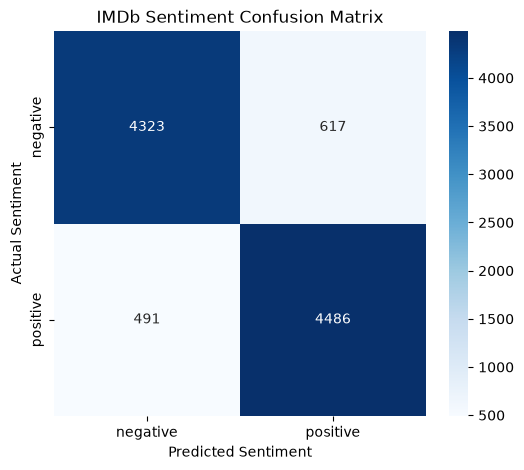

In [61]:
cm = confusion_matrix( y_test, y_pred,  labels=[ "negative","positive"])

plt.figure(figsize=(6, 5))

sns.heatmap(
    cm,
    
    annot=True,
    fmt="d",
    cmap="Blues",
    
    xticklabels=[
        "negative",
        "positive"],
    
    yticklabels=[
        "negative",
        "positive"]
)

plt.xlabel("Predicted Sentiment")
plt.ylabel("Actual Sentiment")

plt.title("IMDb Sentiment Confusion Matrix")

plt.show()

#### `Error Analysis`

##### Counting each error type

In [ ]:


y_test_array = y_test.to_numpy() # convert the y_test series to a numpy array for easier indexing

negative_as_positive = np.where( (y_test_array == "negative") & (y_pred == "positive") )[0] # extract the indices of the samples that are negative but predicted as positive


positive_as_negative = np.where( (y_test_array == "positive") & (y_pred == "negative") )[0] # extract the indices of the samples that are positive but predicted as negative


print("Negative predicted as positive (False Positive): ",  len(negative_as_positive))

print("Positive predicted as negative (False Negative): ",  len(positive_as_negative))

Negative predicted as positive (False Positive):  617
Positive predicted as negative (False Negative):  491


##### Finding all misclassified reviews


In [ ]:

misclassified_indices = np.where( y_test_array != y_pred) [0]

print("Total misclassified reviews:",  len(misclassified_indices))

Total misclassified reviews: 1108


##### Inspecting 3 misclassified examples

In [ ]:

error_indices = [
    negative_as_positive[0],
    positive_as_negative[0],
    negative_as_positive[1]
]

for i in error_indices:

    print("=" * 80)

    print("REVIEW:\n")
    print( X_test.iloc[i])

    print("\nACTUAL SENTIMENT:")
    print( y_test.iloc[i])

    print("\nPREDICTED SENTIMENT:")
    print( y_pred[i])

    print()

REVIEW:

film started got feeling going something special acting camera work undoubtedly good also liked character could grown empathise film good atmosphere hint fantasy. br br however film went plot never appeared takeoff rolled scene scene unable understand connection story could see character occasionally bumping reference ship bottle without connection left unremarkable short stories. br br surprised well cannes

ACTUAL SENTIMENT:
negative

PREDICTED SENTIMENT:
positive

REVIEW:

n't exactly great film admire writer director trying something little different film 's main theme fate small seemingly insignificant thing greatly change future way reminds film sliding door though instead focusing one random event seemingly random stuff happens repeatedly one help build cute conclusion plus odd bald guy seems understand talk one brief scene -- like 's sort omnipotent 's absolutely no explanation film like two guy fight clock tower hudsucker proxy br br dvd jacket show audrey tautou capi

##### Showing confidence for a wrong example

In [ ]:
index = misclassified_indices[0]

review = X_test.iloc[index]

prediction, confidence = predict_sentiment(review)

print("Actual:", y_test.iloc[index])
print("Predicted:", prediction)
print("Confidence:", confidence)

print("\nReview:\n")
print(review)

Actual: positive
Predicted: negative
Confidence: 0.633057275340856

Review:

n't exactly great film admire writer director trying something little different film 's main theme fate small seemingly insignificant thing greatly change future way reminds film sliding door though instead focusing one random event seemingly random stuff happens repeatedly one help build cute conclusion plus odd bald guy seems understand talk one brief scene -- like 's sort omnipotent 's absolutely no explanation film like two guy fight clock tower hudsucker proxy br br dvd jacket show audrey tautou capitalize success amelie though one many actor film no one starring role pace brisk acting fine conclusion n't bad reason n't score higher character bit uninteresting think movie could perhaps tightened less subplots


### `Conclusion`:

#### 1. Model Integration

The IMDb sentiment classification workflow was combined into a complete prediction pipeline.

A raw movie review is first cleaned using the same preprocessing function used during training. The cleaned review is then converted into TF-IDF features and passed to the trained Logistic Regression model.

The following helper functions were used:

- `clean_review()` for text preprocessing.
- `vectorize_review()` for TF-IDF transformation.
- `classify_review()` for sentiment prediction and confidence score.

These were combined into a single `predict_sentiment()` function that takes a raw review and directly returns a positive or negative prediction.

---

#### 2. Training and Prediction Consistency

The same preprocessing and TF-IDF representation used during training were also used during prediction.

The TF-IDF vectorizer was fitted only on the training data using `fit_transform()`.

For new reviews and test data, only `transform()` was used. This ensures that the model receives features based on the same vocabulary and feature space it learned during training.

This prevents differences between the training pipeline and the prediction pipeline.

---

#### 3. Model Evaluation

The trained Logistic Regression model was evaluated on the IMDb test set.

The evaluation included:

- Accuracy
- Precision
- Recall
- F1-score
- Classification report
- Confusion matrix

The confusion matrix was used to examine both types of classification errors:

- Negative reviews predicted as positive.
- Positive reviews predicted as negative.

---

#### 4. Error Analysis

Misclassified reviews were extracted from the test set and inspected individually.

This made it possible to understand why the model made certain mistakes instead of relying only on the overall accuracy score.

Possible causes of errors included:

- Reviews containing both positive and negative opinions.
- Ambiguous sentiment.
- Negation.
- Long or complicated reviews.
- Context that cannot be fully represented by TF-IDF.

---

#### 5. Limitations of TF-IDF

TF-IDF is a useful and efficient text representation method, but it mainly represents the importance of individual words.

It does not fully understand:

- Word order.
- Context.
- Sarcasm.
- Complex sentence meaning.
- How the meaning of a word changes depending on surrounding words.

These limitations can cause sentiment classification errors even when important sentiment words are present.

---

#### 6. Conclusion

This notebook demonstrated how preprocessing, TF-IDF feature extraction, and Logistic Regression classification can be combined into one end-to-end sentiment prediction pipeline.

The model was then evaluated using multiple metrics, followed by confusion-matrix analysis and inspection of misclassified reviews.

The error analysis provided a clearer understanding of both the strengths and limitations of the TF-IDF-based sentiment classification approach.